## Introduction

In this tutorial, you'll learn how to construct confidence intervals for a population mean using a sample. We'll use the `cathedral`  dataset from the `alr4` R package. However, to save time from installing the whole package, you can load the data just using the following line:

In [1]:
cathedral <- readRDS(url('https://github.com/omerfyalcin/colab-data/blob/main/cathedral.rds?raw=true'))

In [2]:
# ggplot2 will be needed
library(ggplot2)

## **Understanding Data**

(This tutorial is adapted from a previous semester's tutorial. Some of the functions below were introduced in the "Descriptive Statistics" tutorial and most of the content until the Confidence Intervals section should already be familiar, but I'll still leave these here as a reminder. -Omer)
  
Today we will discuss various functions to breakdown a dataset and manipulate it to analyze its key features.

1. `data()`: Returns a list of all loaded datasets or loads a dataset.
   b. `data(x)` : Returns a list of specified/currently-loaded datasets.
2. `ls()`: List the names of all the objects present in the current working directory.
3. `head(x, n = number)`: Returns the first n rows of the data set.
4. `tail(x, n = number)`: Returns the last n rows of the data set.
5. `summary(object)`: Produces a summary of various model fitting functions.
6. `nrow(x)`: Returns the number of rows in the specified dataset.
7. `hist(x)`: Creates a histogram bar chart of all the elements in the list dataset.

Where,  
x = input dataset/dataframe. This parameter is necessary.  
n = number of rows that the function should display. If n is not specified, by default 6 rows are displayed.  
object = an object for which a summary is desired.

### **`Introducing the Dataset`**

For this tutorial, we'll use the 'cathedral' data set from the 'alr4' package.
Let's load and inspect the data.

In [3]:
head(cathedral) # print the first six rows

,Type,Height,Length
,<fct>,<int>,<int>
Durham,Romanesque,75,502
Canterbury,Romanesque,80,522
GloucesterRom,Romanesque,68,425
Hereford,Romanesque,64,344
NorwichRom,Romanesque,83,407
Peterborough,Romanesque,80,451


`data()` returns all the available datasets.  
When supplied with a dataset, it attaches that dataset to the environment
`head()` and `tail()` by default return first 6 rows of the specified dataframe.


`summary()` has one required argument: the object whose summary you want. It creates a brief summary of all the columns of this dataset providing us with information such as the minimum, maximum, mean, median, 1st Quantile, 3rd Quantile. `nrow()` returns the total number of rows in a data frame or other rectangular object.

Let's find out the summary of the dataset `cathedral`:

In [4]:
# displaying the summary of the data set
summary(cathedral)
nrow(cathedral)

         Type        Height           Length     
 Gothic    :16   Min.   : 45.00   Min.   :182.0  
 Romanesque: 9   1st Qu.: 67.00   1st Qu.:370.0  
                 Median : 75.00   Median :425.0  
                 Mean   : 75.16   Mean   :429.4  
                 3rd Qu.: 83.00   3rd Qu.:519.0  
                 Max.   :103.00   Max.   :611.0  

[1] 25

`hist()` is typically used to produce a histogram for a numeric vector and is a good data summary tool

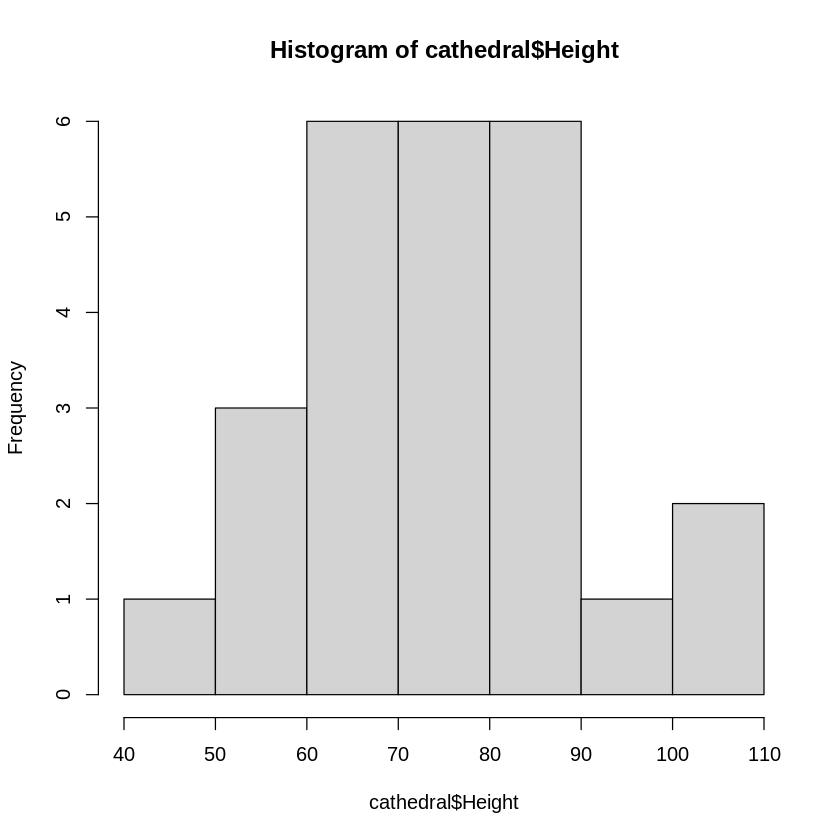

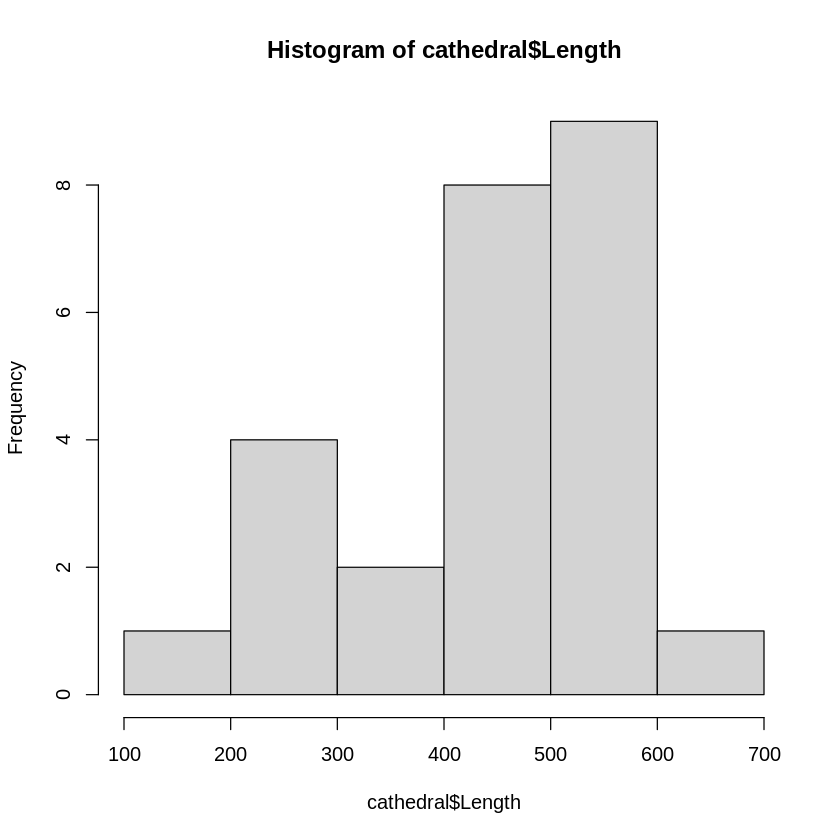

In [5]:
# plot a histogram of the height column of the cathedral dataset
hist(cathedral$Height)
hist(cathedral$Length)

There are various other modifications that can applied on the histogram using `hist()` other functions depending on user's need.  
  
Now, we will create a histogram using `ggplot()`. To use this function, we need to import the `ggplot2` library. It is a R package used for data visualization to create any type of charts. In order to create a histogram, we need to use `geom_histogram` function within the `ggplot()`.  
  
`ggplot()` requires three argument:`list`, `aes()`, and `geom_ function`. `list` is the data of which we want to build the histogram, `aes()` is the aesthetic mapping where we can either a specify column we want to use or mark `x` and `y` axis of the graph, and `geom_` contains a list of graph functions type. For this example, we will use `geom_histogram()`.  

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


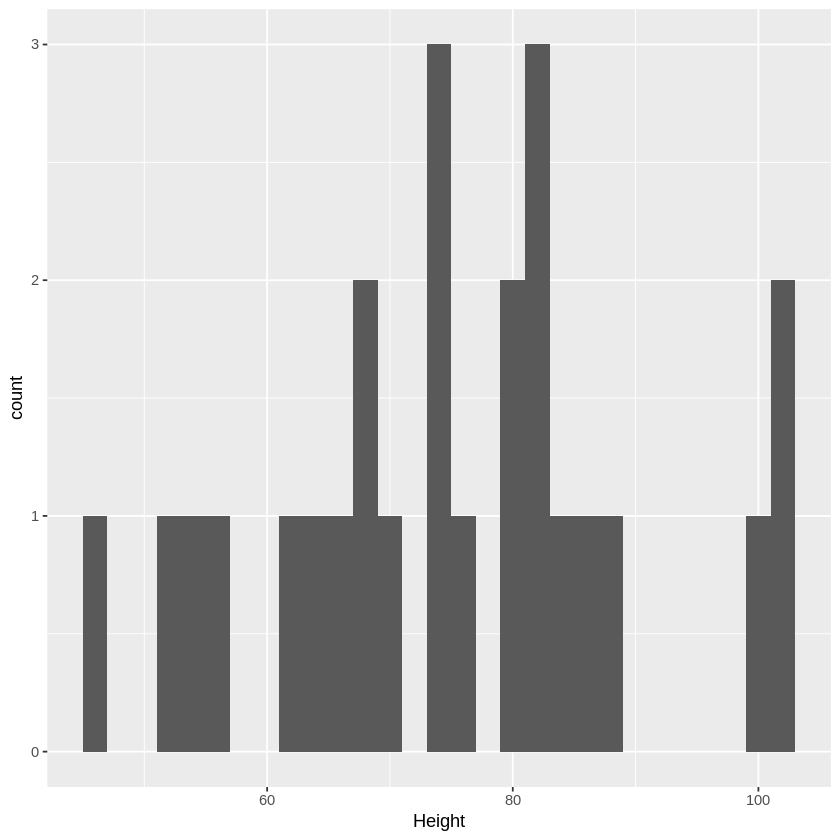

In [6]:
ggplot(cathedral, aes(x = Height)) + geom_histogram()

Write the code to display the histogram for the `Length` column of the `cathedral` dataset?

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


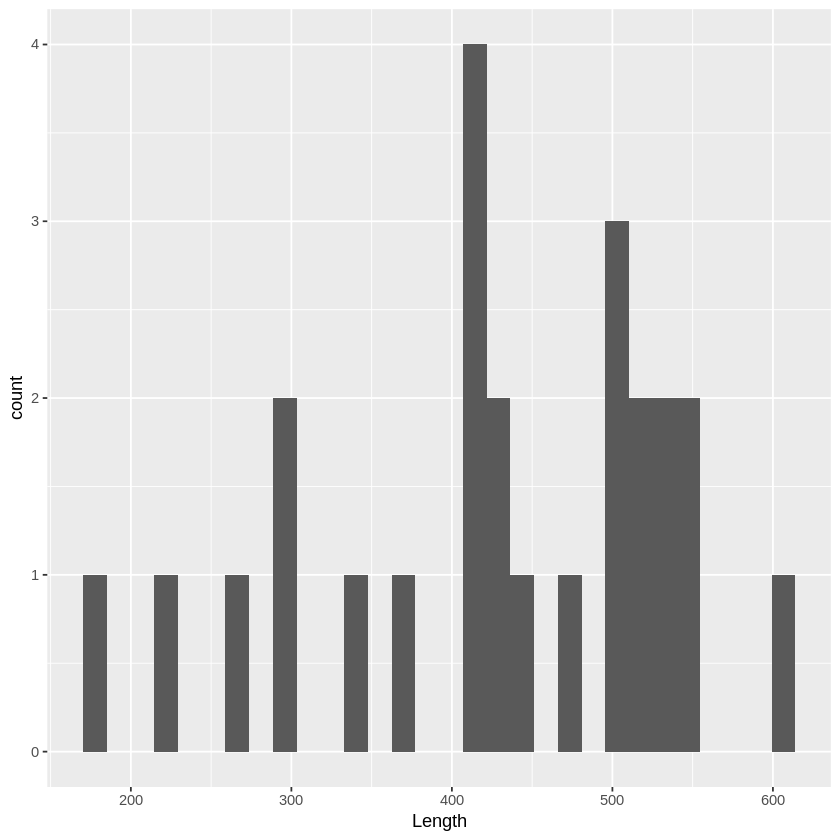

In [7]:
# plot a histogram of the length column of the cathedral dataset
ggplot(cathedral, aes(x = Length)) + geom_histogram()

# **Confidence Intervals**
  
A confidence interval is a range of estimates for an unknown parameter, defined as an interval with a lower bound and an upper bound.
The interval is computed at a designated confidence level, the most common being a confidence level of 95%.
95% of confidence intervals computed at the 95% confidence level contain the true population parameter.

## **Calculating Confidence Interval Manually**

The general formula for a confidence interval is as follows:

$$\displaystyle \mbox{CI} = \bar{X} \pm \left( t \times \frac{s}{\sqrt{n}} \right)$$

The steps to calculate confidence interval:  
  
1. Calculate the sample mean ($\bar{X}$)
2. Calculate the sample standard deviation ($s$)
3. Find out the sample size of the data ($n$)
4. Calculate the standard error ($\frac{s}{\sqrt{n}}$)
4. Determine a confidence level (which we need in order to know what $t$ value to use)
5. Calculate the t-score that corresponds to the confidence level and the sample size (the degrees of freedom of the t distribution is $n-1$)
6. Construct the Confidence Interval using the formula from above  


## Confidence Interval for Cathedral Height

### **`mean()`**  
  
Using the `mean()` function to calculate the average of the height of Cathedral dataset and assigning to a variable.

In [8]:
# calculating sample mean
s_mean <- mean(cathedral$Height)
s_mean

[1] 75.16

### **`sd()`**  
  
Using the `sd()` function to calculate the standard deviation of the Height variable in the Cathedral dataset and assigning it to a variable.

In [9]:
# calculating sample standard deviation
s_sd <- sd(cathedral$Height)
s_sd

[1] 15.01022

### **`length()`**  
  
Using the `length()` function to calculate the sample size of the Cathedral Height variable.

In [10]:
s_size <- length(cathedral$Height)
s_size

[1] 25

### Calculate the Standard Error

In [11]:
standard_error <- s_sd / sqrt(s_size)
standard_error

[1] 3.002044

### Specify a confidence level, calculate the area of the two tails.

In [12]:
confidence_level <- 0.95
# how much area should be in each tail of the distribution for 95% to be in the middle?
tail_area <- (1-confidence_level)/2
tail_area

[1] 0.025

### **`t-values`**  
  
To calculate t-values (or t-scores), we will use the **`qt()`** function from previous tutorial.  

In [13]:
# calculating the t score using qt()
t_score <- qt(p = 1-tail_area, df = s_size-1)
t_score

[1] 2.063899

### **`Confidence Interval`**  
  
To calculate the confidence interval using the formula:

In [14]:
# computing above calculations in a formula to calculate confidence interval
CI <- c(s_mean - t_score * standard_error,
        s_mean + t_score * standard_error)
print(CI)

[1] 68.96409 81.35591


Note that the `t_score * standard_error` part is also known as the `margin of error`. In this example, it works out to:

In [15]:
t_score * standard_error

[1] 6.195914


## Confidence Interval for Cathedral Length

Your turn:

calculate the **90%** confidence interval for Cathedral **Length** manually:

In [16]:
l_mean = mean(cathedral$Length)
l_mean

[1] 429.44

In [17]:
l_sd = sd(cathedral$Length)
l_sd

[1] 110.337

In [18]:
l_size = length(cathedral$Length)
l_size

[1] 25

In [19]:
l_standard_error <- l_sd / sqrt(l_size)
l_standard_error

[1] 22.0674

In [20]:
l_standard_error * 1.645

[1] 36.30088

In [21]:
confidence_level <- 0.90
l_tail_area <- (1-confidence_level)/2
l_tail_area

[1] 0.05

In [22]:
# calculating the t score using qt()
l_t_score <- qt(p = 1-l_tail_area, df = l_size-1)
l_t_score

[1] 1.710882

In [23]:
# computing above calculations in a formula to calculate confidence interval
l_CI <- c(l_mean - l_t_score * l_standard_error,
          l_mean + l_t_score * l_standard_error)
print(l_CI)

[1] 391.6853 467.1947


In [26]:
# mean


# standard deviation


# sample size


# standard error


# t-value


# plug everything back in





## Confidence Interval using `t.test()`

We can use the `t.test()` function to estimate the confidence interval in one line:

In [27]:
t.test(cathedral$Height)


	One Sample t-test

data:  cathedral$Height
t = 25.036, df = 24, p-value < 2.2e-16
alternative hypothesis: true mean is not equal to 0
95 percent confidence interval:
 68.96409 81.35591
sample estimates:
mean of x 
    75.16 


Parts of the output might not be familiar to you yet, but the part that says "95 percent confidence interval:" should me matching what we manually found for Cathedral Height. We could also just isolate the confidence interval:

In [28]:
t.test(cathedral$Height)$conf.int

[1] 68.96409 81.35591
attr(,"conf.level")
[1] 0.95

Notice that the function by default calculates the 95% confidence interval. So, if you ran `t.test(cathedral$Length)`, it would not give you the 90% confidence interval you found. To get the 90% confidence interval, you should use the argument `conf.level = 0.9`. Try it out below. Does it match what you manually found?

In [29]:
# Write code here:
t.test(cathedral$Length, conf.level = 0.9)$conf.int

[1] 391.6853 467.1947
attr(,"conf.level")
[1] 0.9